# CoLoRA: Convolutional Low-Rank Adaptation for OCT Image Classification

**Author**: Mariano Rivera  
**Institution**: CIMAT (Centro de Investigación en Matemáticas)  
**Version**: 0.8 (January 2024)

## Overview

This notebook implements **CoLoRA** (Convolutional Low-Rank Adaptation) for classifying optical coherence tomography (OCT) images for retinal disease diagnosis.

### Dataset: OCTMNIST
- 4 diagnosis categories
- 224×224 grayscale images
- Classes: CNV, DME, Drusen, Normal

### Key Improvements
- ✅ Balanced dataset handling
- ✅ Low-rank adaptation for efficient fine-tuning
- ✅ Comprehensive evaluation metrics
- ✅ Clean, well-documented code

## 1. Environment Setup

Configure CUDA and suppress unnecessary warnings.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"

import warnings
warnings.filterwarnings('ignore')

## 2. Import Required Libraries

In [2]:
import time
import keras
import medmnist
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from keras import layers
from keras.models import Model
from keras.models import Sequential
from keras.applications import VGG16
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.10.0
Keras version: 2.10.0


## 3. Configuration Parameters

Define all hyperparameters and constants.

In [3]:
# Dataset configuration
DATASET_NAME = 'octmnist'
IMAGE_SIZE = 224
N_CHANNELS = 3
NUM_CLASSES = 4

# Training configuration
BATCH_SIZE = 16
EPOCHS = 5
AUTO = tf.data.AUTOTUNE

# Class labels
CLASS_LABELS = {
    0: "Choroidal Neovascularization",
    1: "Diabetic Macular Edema",
    2: "Drusen",
    3: "Normal"
}

print(f"Dataset: {DATASET_NAME}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Batch Size: {BATCH_SIZE}")

Dataset: octmnist
Image Size: 224x224
Number of Classes: 4
Batch Size: 16


## 4. Data Loading and Preparation

Load the OCTMNIST dataset and prepare it for training.

In [4]:
def download_and_prepare_dataset_balanced(data_info: dict, image_size: str = ""):
    """Download and prepare the balanced OCTMNIST dataset."""
    url = "url" + "_" + image_size if image_size != "" else "url"
    md5 = "MD5" + "_" + image_size if image_size != "" else "MD5"
    
    data_path = keras.utils.get_file(
        origin=data_info[url],
        md5_hash=data_info[md5]
    )
    
    print("Data path:", data_path)
    
    with np.load(data_path) as data:
        # Load balanced training data
        train_images = np.expand_dims(data["train_images"], axis=-1)
        val_images   = np.expand_dims(data["val_images"],   axis=-1)
        test_images  = np.expand_dims(data["test_images"],  axis=-1)
        
        # Load validation and test data
        train_labels = keras.utils.to_categorical(data["train_labels"].flatten(), num_classes=NUM_CLASSES)
        val_labels   = keras.utils.to_categorical(data["val_labels"].flatten(),   num_classes=NUM_CLASSES)
        test_labels  = keras.utils.to_categorical(data["test_labels"].flatten(),  num_classes=NUM_CLASSES)
    
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

In [5]:
# Get dataset info
info = medmnist.INFO[DATASET_NAME]

# Download and prepare data
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = \
    download_and_prepare_dataset_balanced(info, str(IMAGE_SIZE))

print(f"\nTrain dataset:      {train_images.shape} {train_labels.shape}")
print(f"Validation dataset: {val_images.shape} {val_labels.shape}")
print(f"Test dataset:       {test_images.shape} {test_labels.shape}")

Data path: /home/ajhoyos/.keras/datasets/octmnist_224.npz

Train dataset:      (97477, 224, 224, 1) (97477, 4)
Validation dataset: (10832, 224, 224, 1) (10832, 4)
Test dataset:       (1000, 224, 224, 1) (1000, 4)


## 5. Data Visualization

Visualize class distribution and sample images.

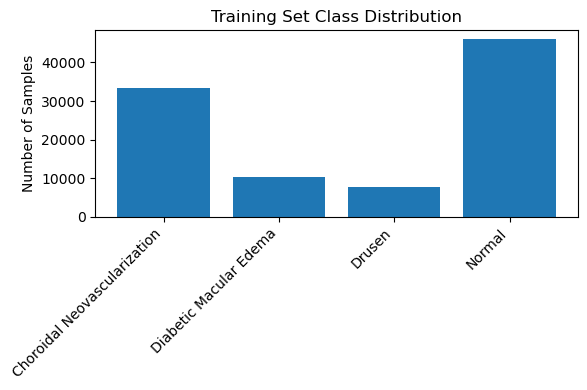

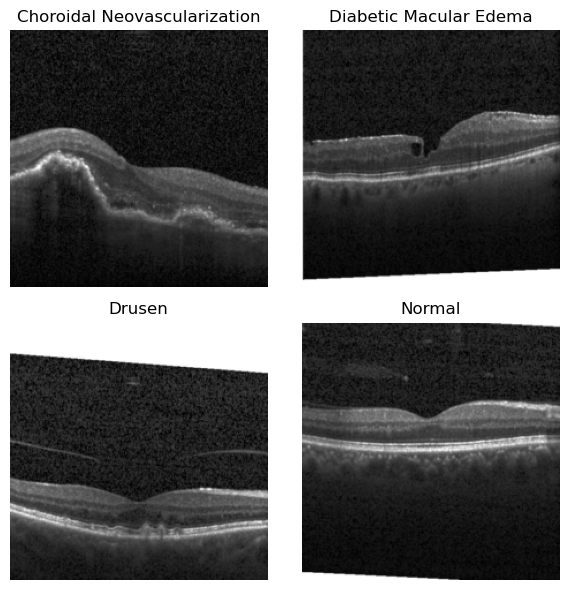

In [6]:
# Plot class distribution
plt.figure(figsize=(6, 4))
class_counts = np.sum(train_labels, axis=0)
plt.bar(range(NUM_CLASSES), class_counts)
plt.xticks(range(NUM_CLASSES), [CLASS_LABELS[i] for i in range(NUM_CLASSES)], rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.title('Training Set Class Distribution')
plt.tight_layout()

# Show sample images
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for idx, class_id in enumerate(range(NUM_CLASSES)):
    sample_idx = np.where(np.argmax(train_labels, axis=1) == class_id)[0][0]
    ax = axes[idx // 2, idx % 2]
    ax.imshow(train_images[sample_idx].squeeze(), cmap='gray')
    ax.set_title(CLASS_LABELS[class_id])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Data Preprocessing Pipeline

Implement augmentation and normalization.

In [ ]:
def augment_img(image, label):
    """Apply data augmentation."""
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_flip_left_right(image)
    return image, label

def normalize_img(image, label):
    """Normalize image pixels to [0, 1] range."""
    image = tf.image.grayscale_to_rgb(image)
    return tf.cast(image, tf.float32) / 255.0, label

# Calculate steps
num_train = train_images.shape[0]
steps_per_epoch = int(np.ceil(num_train / float(BATCH_SIZE)))

# Create TensorFlow datasets
ds_train = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
ds_val = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
ds_test = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

# Prepare training dataset with augmentation
ds_train = (ds_train
            .map(augment_img, num_parallel_calls=AUTO)
            .map(normalize_img, num_parallel_calls=AUTO)
            .cache()
            .shuffle(buffer_size=1000)
            .batch(BATCH_SIZE)
            .prefetch(AUTO))

# Prepare validation dataset
ds_val = (ds_val
          .map(normalize_img, num_parallel_calls=AUTO)
          .cache()
          .batch(1)
          .prefetch(AUTO))

# Prepare test dataset
ds_test = (ds_test
           .map(normalize_img, num_parallel_calls=AUTO)
           .cache()
           .batch(1)
           .prefetch(AUTO))

print(f"Steps per epoch: {steps_per_epoch}")
print("Datasets prepared successfully!")

Steps per epoch: 6093
Datasets prepared successfully!


In [8]:
for image, label in ds_train.take(3):
    print(image[0].numpy().shape, '\n', label[0].numpy())  

(224, 224, 3) 
 [0. 0. 0. 1.]
(224, 224, 3) 
 [0. 0. 0. 1.]
(224, 224, 3) 
 [0. 0. 0. 1.]


## 7. CoLoRA Layer Implementation

Define the Convolutional Low-Rank Adaptation layer.

In [9]:
def Create_Colora_config(Layer):
    layer_config = Layer.get_config()
    shared_keys = ['name', 'trainable', 'dtype', 'filters', 'kernel_size', 'strides', 'padding', 'data_format', 'dilation_rate', 'activation', 'use_bias']

    colora_config={}
    for k in shared_keys:
        colora_config[k] = layer_config[k]

    colora_config['name'] = colora_config['name']+'_colora'
    colora_config['depthwise_initializer'] = {'module'         : 'keras.initializers',
                                              'class_name'     : 'Zeros',
                                              'config'         : {},
                                              'registered_name': None, }      
    return colora_config

In [10]:
class Colora2D(keras.layers.Layer):
    def __init__(self, original_layer, trainable=True, **kwargs):
        """
        Receives a keras.layers.Layer Convolutional2D layer (inserted in a model) 
        and adds a parallel link with a separable convolutional 2D layer with 
        compatible filters; i.e. They can be fused.
        """
        # Keep the same as the original convolutional layer.
        original_layer_config = original_layer.get_config()
        name                  = original_layer_config["name"]+'_Colora'
        kwargs.pop("name", None)
        super().__init__(name=name, trainable=trainable, **kwargs)
       
        # ---- Layers----
        # Original Conv2D layer with frozen parameters
        self.original_layer = original_layer
        self.original_layer.trainable = False

        # Separable Conv2D layer, trainable        
        colora_config  = Create_Colora_config(original_layer)
        self.sep_conv_layer = keras.layers.SeparableConv2D.from_config(colora_config)

    
    def call(self, inputs):
        original_output = self.original_layer(inputs)
        # Add LoRA layers' output to the original layer's output.
        colora_output =self.sep_conv_layer(inputs)
        return original_output + colora_output

    def call_after_filter_merge(self, inputs):
        original_output = self.original_layer(inputs)
        if self.trainable:
            # If we are fine-tuning the model, we will add CoLoRA layers' output
            # to the original layer's output.
            colora_output = self.sep_conv_layer(inputs)
            return original_output + colora_output  
        return original_output

    def merge_filters(self):
        """
        1. Get weights: We retrieve the weights for both the Conv2D and SeparableConv2D layers. 
          The Conv2D layer has one kernel and a bias, while the SeparableConv2D has depthwise 
          and pointwise kernels, plus a bias.
        2. Combine depthwise and pointwise kernels: The depthwise kernel applies channel-wise 
          convolution, and the pointwise kernel combines these into the output channels. 
          We multiply them to produce a kernel with the same shape as the Conv2D kernel.
        3. Add the kernels: The combined SeparableConv2D kernels are added to the Conv2D kernel.
        4. Set weights: The newly combined kernel is assigned to the Conv2D layer.
        5. Reset CoLoRA
        """

        # Get weights from both layers
        conv_weights     = self.original_layer.get_weights() # Regular Conv2D: [kernel, bias]
        sep_conv_weights = self.sep_conv_layer.get_weights() # SeparableConv2D: [depthwise_kernel, pointwise_kernel, bias]
        
        # Extract kernels and biases from both layers
        conv_kernel = conv_weights[0]           # Shape: (kernel_height, kernel_width, input_channels, output_channels)
        conv_bias   = conv_weights[1]           # Shape: (output_channels,)
        depthwise_kernel = sep_conv_weights[0]  # Shape: (kernel_height, kernel_width, input_channels, output_channels)
        pointwise_kernel = sep_conv_weights[1]  # Shape: (1, 1, input_channels, output_channels)
        sep_conv_bias    = sep_conv_weights[2]  # Shape: (output_channels,)
        
        # Adjust the depthwise kernel to match Conv2D shape by combining with pointwise kernel
        # The depthwise kernel will be broadcasted across the output channels by the pointwise kernel
        sep_conv_combined_kernel = np.zeros_like(conv_kernel)
        sep_conv_combined_kernel = depthwise_kernel * pointwise_kernel
        
        # Add the two kernels and biases
        new_conv_kernel = conv_kernel + sep_conv_combined_kernel
        new_conv_bias   = conv_bias   + sep_conv_bias
        
        # Set the new weights to the Conv2D layer (including combined biases)
        self.original_layer.set_weights([new_conv_kernel, new_conv_bias])

        # Set the pointwise kernel and bias to zeros
        new_pointwise_kernel = np.zeros_like(pointwise_kernel)
        new_sep_bias         = np.zeros_like(sep_conv_bias)

        # Set the new weights back to the layer (with the depthwise kernel unchanged)
        self.sep_conv_layer.set_weights([depthwise_kernel, new_pointwise_kernel, new_sep_bias])
        
        return
        
    def get_training_level(self):
        return [self.original_layer.trainable,            
                self.sep_conv_layer.trainable]
        
    def set_training_mode(self, mode='tuning'):
        if mode=='tuning':        # fine tuning by LoRa approach
            self.original_layer.trainable = False
            self.sep_conv_layer.trainable = True
        elif mode=='original':    # trains only the original layer 
            self.original_layer.trainable = True
            self.sep_conv_layer.trainable = False
            
        elif mode=='full':        # trains both layers
            self.original_layer.trainable = True
            self.sep_conv_layer.trainable = True
            
        elif mode=='freaze':      # set no trainable both layers
            self.original_layer.trainable = False
            self.sep_conv_layer.trainable = False
            #print(mode)
        else:
            self.original_layer.trainable = False
            self.sep_conv_layer.trainable = False
        return

In [11]:
layer_names= ['block1_conv1', 'activa1_1', 'block1_conv2', 'activa1_2',                              'block1_pool',
              'block2_conv1', 'activa2_1', 'block2_conv2', 'activa2_2',                              'block2_pool',
              'block3_conv1', 'activa3_1', 'block3_conv2', 'activa3_2', 'block3_conv3', 'activa3_3', 'block3_pool', 
              'block4_conv1', 'activa4_1', 'block4_conv2', 'activa4_2', 'block4_conv3', 'activa4_3', 'block4_pool', 
              'block5_conv1', 'activa5_1', 'block5_conv2', 'activa5_2', 'block5_conv3', 'activa5_3', 'block5_pool',
              'flatten_5', 'fc_1', 'fc_2',]

def vgg16_in_keras(extended = True):
    """
    """
    activation_conv = None if extended else 'relu'

    inputs = keras.Input(shape=(224,224,3))
    x = layers.Conv2D(filters=64,kernel_size=(3,3),padding="same", activation=activation_conv, name=layer_names[0])(inputs)
    if extended: x = layers.Activation('relu', name=layer_names[1])(x)
    x = layers.Conv2D(filters=64,  kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[2])(x)
    if extended: x = layers.Activation('relu', name=layer_names[3])(x)
    x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2), name=layer_names[4])(x)
    x = layers.Conv2D(filters=128, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[5])(x)
    if extended: x = layers.Activation('relu', name=layer_names[6])(x)
    x = layers.Conv2D(filters=128, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[7])(x)
    if extended: x = layers.Activation('relu', name=layer_names[8])(x)
    x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2), name=layer_names[9])(x)
    x = layers.Conv2D(filters=256, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[10])(x)
    if extended: x = layers.Activation('relu', name=layer_names[11])(x)
    x = layers.Conv2D(filters=256, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[12])(x)
    if extended: x = layers.Activation('relu', name=layer_names[13])(x)
    x = layers.Conv2D(filters=256, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[14])(x)
    if extended: x = layers.Activation('relu', name=layer_names[15])(x)
    x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2), name=layer_names[16])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[17])(x)
    if extended: x = layers.Activation('relu', name=layer_names[18])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[19])(x)
    if extended: x = layers.Activation('relu', name=layer_names[20])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[21])(x)
    if extended: x = layers.Activation('relu', name=layer_names[22])(x)
    x = layers.MaxPool2D(pool_size=(2,2),strides=(2,2), name=layer_names[23])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[24])(x)
    if extended: x = layers.Activation('relu', name=layer_names[25])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[26])(x)
    if extended: x = layers.Activation('relu', name=layer_names[27])(x)
    x = layers.Conv2D(filters=512, kernel_size=(3,3), padding="same", activation=activation_conv, name=layer_names[28])(x)
    if extended: x = layers.Activation('relu', name=layer_names[29])(x)
    outputs = layers.MaxPool2D(pool_size=(2,2),strides=(2,2), name=layer_names[30])(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="vgg16")
    
    return model


def vgg16_clone_extended(original_backbone=None, verbose=False):
    """
    Given a VGG16 backbone, creates a clone with split convolutional and activations layers
    """
    clone_backbone = vgg16_in_keras()
    for k,layer in enumerate(original_backbone.layers):     
        if verbose: print(layer.name)
        if layer.__class__.__name__ == 'Conv2D':
            name = layer.name
            for offset,clone_layer in enumerate(clone_backbone.layers[k:]):
                if clone_layer.name == name:
                    clone_backbone.layers[k+offset].set_weights(original_backbone.layers[k].get_weights())
                    if verbose: print(k, ' - ', k+offset, name, ' ', clone_layer.name)
                    k=k+offset
    
    return clone_backbone

In [12]:
def vggColora(original_model, verbose=False):
    '''
    Given a VGG model, transform each layer with "filters" into 
    a CoLoRA layer (Convolutional2D -> Colora2D). It adds a parallel
    separable convolution to the original convolutional layer
    '''
    new_model = Sequential()
    for layer in original_model.layers[1:]:
        if verbose: 
            print(layer.name)
        if layer.name =='vgg16':        # if the layer is the backbone
            for intern_layer in layer.layers:      # for layers in backnone
                if verbose: 
                    print(' - ', intern_layer.name)
                if intern_layer.__class__.__name__ == 'Conv2D':
                    colora2D = Colora2D(intern_layer)
                    new_model.add(colora2D)
                    if verbose: 
                        print('   + colora')
                else:
                    new_model.add(intern_layer)  # nothing to do
        else:
            new_model.add(layer)        # nothing to do
        
    return new_model

    
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
def vggColora_set_training(model, mode='tuning'):
    '''
    Set training mode to the Colora layers in the "model"

    mode:   "tuning",  fine-tuning by LoRa approach (just the Separable)
            "original" trains only the original layer (just the Conv2D)
            "full"     trains both layers (Conv2D + Separable)
            "freaze"   set no trainable both layers
             other  = "freaze"  
    '''
    for layer in model.layers:
        # cleck layer class
        if layer.__class__.__name__ == 'Colora2D' :
            layer.set_training_mode(mode=mode)
    return

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
def vggColora_merge_filters(model):
    '''
    Fuse the separable convolutional weights into the standard convolutional layer
    '''
    for layer in model.layers:
        # cleck layer class
        if layer.__class__.__name__ == 'Colora2D' :
            layer.merge_filters()
    return

## 8. Model Architecture

Create VGG16-based model with CoLoRA adaptations.

In [13]:
def create_VGG16_CoLoRA_model():
    '''
    VGG16 based model with pretrained weights
    '''
    backbone = VGG16(weights     = 'imagenet',
                     include_top = False,
                     input_shape = (224, 224, 3))
    
    extended_backbone =vgg16_clone_extended(backbone)
    
    del backbone
    
    extended_backbone.trainable = False

    inputs  = keras.Input(shape=(224, 224, 3))

    x       = extended_backbone(inputs, training=False)
    x       = keras.layers.Flatten()(x)
    x       = keras.layers.Dense(units=128, activation='relu', name='fc_1')(x)  
    
    outputs = keras.layers.Dense(units=NUM_CLASSES, name='fc_2')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="vgg16_based")
    
    return model, extended_backbone

In [14]:
# Create model
vgg_model, backbone = create_VGG16_CoLoRA_model()

print("Model created successfully!")
vgg_model.summary()

Model created successfully!
Model: "vgg16_based"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 fc_1 (Dense)                (None, 128)               3211392   
                                                                 
 fc_2 (Dense)                (None, 4)                 516       
                                                                 
Total params: 17,926,596
Trainable params: 3,211,908
Non-trainable params: 14,714,688
_________________________________________________________________


In [15]:
vgg_colora=vggColora(vgg_model)
vggColora_set_training(vgg_colora, mode='tuning') #'freaze')
vgg_colora.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1_Colora (Colora  (None, 224, 224, 64)     2075      
 2D)                                                             
                                                                 
 activa1_1 (Activation)      (None, 224, 224, 64)      0         
                                                                 
 block1_conv2_Colora (Colora  (None, 224, 224, 64)     41664     
 2D)                                                             
                                                                 
 activa1_2 (Activation)      (None, 224, 224, 64)      0         
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1_Colora (Colora  (None, 112, 112, 128)    8

## 9. Model Training

Train the model with prepared datasets.

In [16]:
# Set up callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [ ]:
def train_procedure(epochs=3, batch_size=16, SHOW_DETAILS=False):
    max_acc = 0
                             
    vgg_model, vgg_backbone = create_VGG16_CoLoRA_model()           # VGG16-based exdended model and backbone extended with pretrained weights
    vgg_colora              = vggColora(vgg_model)     # Create the COLORA version

    # Set COLORA fine-tuning
    vggColora_set_training(vgg_colora, 
                            mode='tuning') #'freaze')
    
    vgg_colora.compile(loss      = keras.losses.BinaryCrossentropy(from_logits=True),
                        optimizer = 'adam',
                        metrics   = ['accuracy'])
    
    if SHOW_DETAILS:
        vgg_backbone.summary()
        vgg_model.summary()
        vgg_colora.summary
        
    # Train
    tic = time.time()
    history = vgg_colora.fit(ds_train,
                             epochs    = epochs,
                             shuffle   = True,
                             callbacks = [callbacks])
    
    secs = (time.time()-tic)/60

    # Evaluate performance 
    val_loss, val_accuracy = vgg_colora.evaluate(ds_val)
    loss, accuracy         = vgg_colora.evaluate(ds_test)
    
    # Save metrics
    with open(f'results_VGG16_CoLoRA_OCT_MedMNIST.txt', 'a') as file:
        file.write(f"{t}:\n")
        file.write(f"  Val Loss:      {val_loss},\n")
        file.write(f"  Val Accuracy:  {val_accuracy},\n")
        file.write(f"  Test Loss:     {loss},\n")
        file.write(f"  Test Accuracy: {accuracy},\n")
        file.write(f"  Time:          {secs},\n")
    
    # Print metrics
    if accuracy>max_acc: 
        max_acc = accuracy
        print(f"{t}:")
        print(f"Test Loss:     {loss},")
        print(f"Test Accuracy: {accuracy},")
        print(t,'*',t,'*',t,'*',t,'*',t)
        vggColora_merge_filters(vgg_colora)
        vgg_model.save(f'VGG16_CoLoRA_OCT_MedMNIST.keras', overwrite=True, include_optimizer=False)

    del vgg_backbone
    del vgg_model
    del vgg_colora
        
    return 

: 

In [ ]:
train_procedure(epochs=1)

323/677 [=============>................] - ETA: 36s - loss: 0.0503 - accuracy: 0.9677

## 10. Model Evaluation

Evaluate model performance on test set.

In [ ]:
colora_vgg16 = keras.models.load_model('VGG16_CoLoRA_3_OCT_MedMNIST.keras')

colora_vgg16.compile(loss      = keras.losses.BinaryCrossentropy(from_logits=True),
                     optimizer = 'adam',
                     metrics   = ['accuracy'])

vggColora_set_training(colora_vgg16, 
                       mode='freaze')

# Show the model architecture
colora_vgg16.summary()

In [ ]:
# Get predictions
print("Generating predictions...")
y_pred = colora_vgg16.predict(ds_test)

# Get ground truth
Y_gt = []
for _, labels in ds_test:
    Y_gt.append(labels.numpy())
Y_gt = np.concatenate(Y_gt, axis=0)

# Calculate metrics
loss, accuracy = colora_vgg16.evaluate(ds_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Confusion matrix
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(Y_gt, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# ROC AUC scores
print("\nROC AUC Scores by Class:")
for class_id in range(NUM_CLASSES):
    try:
        roc_auc = roc_auc_score(Y_gt[:, class_id], y_pred[:, class_id])
        print(f"  {CLASS_LABELS[class_id]}: {roc_auc:.4f}")
    except:
        print(f"  {CLASS_LABELS[class_id]}: N/A")

## 11. Results Visualization

Generate confusion matrix and ROC curves.

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
    yticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)]
)

plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot ROC curves
plt.figure(figsize=(15, 4))
for class_id in range(NUM_CLASSES):
    plt.subplot(1, NUM_CLASSES, class_id + 1)
    
    try:
        fpr, tpr, _ = roc_curve(Y_gt[:, class_id], y_pred[:, class_id])
        auc_score   = roc_auc_score(Y_gt[:, class_id], y_pred[:, class_id])
        
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{CLASS_LABELS[class_id]}\n(AUC = {auc_score:.3f})')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
    except:
        plt.text(0.5, 0.5, 'Not enough data', ha='center', va='center')

plt.tight_layout()
plt.savefig('roc_curves_test.png', dpi=300, bbox_inches='tight')
plt.show()